# Pipeline Comparison: 02_LIBS_classification vs. an exploratory alternative

`02_LIBS_classification.ipynb` uses one specific preprocessing pipeline (global min-max normalization, a single broad spectral region, a constant baseline). A separate exploratory notebook (`TestALaCa.ipynb`, private repo) tried a different one: filtering out low-signal spectra first, normalizing each spectrum relative to a single calcium line instead of its own min/max, and restricting to a few narrow zones around known emission lines instead of one broad region.

Both notebooks happen to use the exact same training experiments (F1 vs. N1) and the exact same held-out generalization specimens, so we can compare the two preprocessing pipelines directly: same raw data, same downstream models (a Random Forest and the feedforward network from `02_LIBS_classification.ipynb`), same overall spectral range (390–532 nm), only the region *structure* and normalization differ. This isolates the effect of those preprocessing choices from the effect of model choice or wavelength coverage.

In [1]:
%matplotlib inline

# Standard library
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Deep learning
import tensorflow as tf

# Local modules
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from ML_libs.data_wrangling import condense_and_join

# The neural network results below are cited by number in the discussion;
# fix all RNGs, and force deterministic ops, so re-running this notebook
# reproduces the same figures (seeding alone is not enough for TensorFlow).
tf.keras.utils.set_random_seed(127)
tf.config.experimental.enable_op_determinism()

2026-09-02 23:06:28.585465: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-02 23:06:28.648462: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-02 23:06:28.649435: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-02 23:06:29.487003: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/usr/lib/python3/dist-packages/requests/__init__.py:89: RequestsDependencyWarning: urllib3 (2.2.3) or chardet (3.0.4) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


## Load the raw data

Same training experiments used in both `02_LIBS_classification.ipynb` and `TestALaCa.ipynb`: two acquisitions of F1's first bone sample, and two acquisitions of N1's second bone sample.

In [2]:
path_to_raw = str(project_root / "raw_data")

selected_experiments = [
    "F1-muestra 1-log_09ago.24_111305-ascii",
    "N1-muestra 2-log_08ago.24_102720-ascii",
    "F1-muestra 1-log_09ago.24_112021-ascii",
    "N1-muestra 2-log_08ago.24_103401-ascii",
]

seg = "Merge0"
condense_and_join.condense(selected_experiments, path_to_raw, seg, test=False)
df = condense_and_join.join_data(path_to_raw, selected_experiments, seg=seg)
print(df.shape)

/home/matias/Documents/ML-libs/spectral-classification-toolkit/raw_data/F1-muestra 1-log_09ago.24_111305-ascii
/home/matias/Documents/ML-libs/spectral-classification-toolkit/raw_data/N1-muestra 2-log_08ago.24_102720-ascii
/home/matias/Documents/ML-libs/spectral-classification-toolkit/raw_data/F1-muestra 1-log_09ago.24_112021-ascii
/home/matias/Documents/ML-libs/spectral-classification-toolkit/raw_data/N1-muestra 2-log_08ago.24_103401-ascii
(400, 6085)


## The two preprocessing pipelines

**Continuous-region pipeline** (`02_LIBS_classification.ipynb`): normalize each spectrum to its own [0, 1] range, restrict to one continuous window (390–532 nm — matched to the targeted-zone pipeline's overall span, see below), then drop wavelength channels below a constant baseline. (The original notebook actually uses 250–400 nm; narrowed here to 390–532 nm so both pipelines cover the exact same spectral range and only their *structure* differs.)

**Targeted-zone pipeline** (`TestALaCa.ipynb`): first drop spectra with weak signal at the Ca II 393.37 nm line (a signal-quality filter — this changes the *number of spectra*, not just their values), normalize every spectrum relative to that same Ca line instead of its own min/max, restrict to three narrow zones around known emission lines (390–410, 420–480, 516–532 nm) instead of one continuous window, then drop wavelength channels below a constant baseline (on a different scale, since the data is peak-normalized rather than min-max normalized).

Both are split into a `_features` step (shared between training and later generalization data) and a final baseline-removal step (which fixes the feature set — done once, on training data only).

In [3]:
def continuous_region_features(df):
    df_norm = condense_and_join.normalize_dataframe(df)
    return condense_and_join.select_region(df_norm, xmin=390, xmax=532)


def targeted_zone_features(df):
    df_filt = condense_and_join.filtter_noise_spec(df, peak=393.37, w=0.5, sigma=0.3)
    df_norm = condense_and_join.normalize_dataframe_to(df_filt, peak=393.37, w=1)
    zone1 = condense_and_join.select_region(df_norm, xmin=390, xmax=410)
    zone2 = condense_and_join.select_region(df_norm, xmin=420, xmax=480)
    zone3 = condense_and_join.select_region(df_norm, xmin=516, xmax=532)
    df_zones = pd.concat([zone1, zone2, zone3], axis=1)
    return df_zones.loc[:, ~df_zones.columns.duplicated()]

In [4]:
df_cont_train = condense_and_join.remove_baseline(continuous_region_features(df), type="constant", level=0.011)
df_zone_train = condense_and_join.remove_baseline(targeted_zone_features(df), type="constant", level=0.05)

print(f"Continuous-region: {df_cont_train.shape[0]} spectra, {df_cont_train.shape[1] - 2} features")
print(f"Targeted-zone: {df_zone_train.shape[0]} spectra, {df_zone_train.shape[1] - 2} features")

average:17039.29, min:11927.5, max:22151.08
you are getting 275 from 400 spects
Continuous-region: 400 spectra, 224 features
Targeted-zone: 275 spectra, 176 features


The targeted-zone pipeline's spectra count is lower than the continuous-region pipeline's: its signal-quality filter removes some spectra outright, before any model ever sees them.

## Side-by-side: the same spectra, after each pipeline

Since the targeted-zone pipeline only removes spectra (never adds any), any spectrum present in `df_zone_train` is also present in `df_cont_train` at the same row index. We pick a handful of spectra common to both and plot them after each pipeline's preprocessing, so the two panels show the *same underlying acquisitions*.

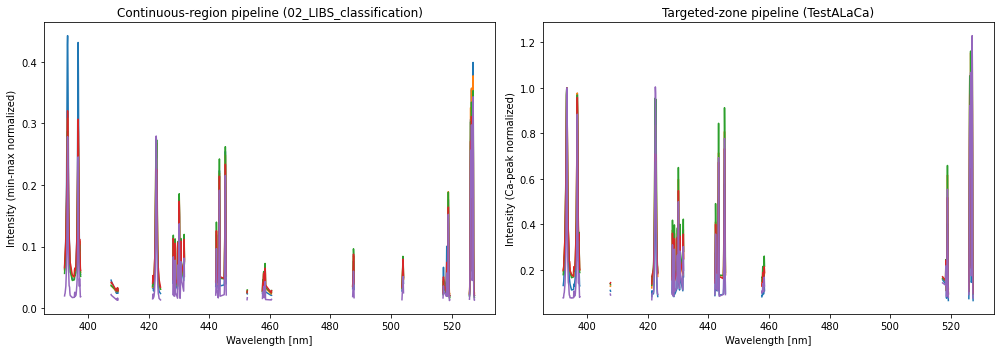

In [5]:
def with_gap_breaks(df_wide, gap_threshold=2.0):
    """Insert a NaN column wherever consecutive wavelength columns are more
    than gap_threshold nm apart, so line plots don't draw a straight
    (misleading) line across a dropped/zone-boundary gap."""
    cols = sorted(df_wide.columns)
    pieces = [df_wide[[cols[0]]]]
    for prev_c, c in zip(cols, cols[1:]):
        if (c - prev_c) > gap_threshold:
            pieces.append(pd.DataFrame(np.nan, index=df_wide.index, columns=[(prev_c + c) / 2]))
        pieces.append(df_wide[[c]])
    return pd.concat(pieces, axis=1)


common_idx = df_zone_train.index[:5]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# Plain matplotlib (not sns.lineplot): its long-form/CI machinery does not
# reliably preserve NaN gaps as visual breaks, so it would still draw a
# straight line across the dropped/zone-boundary gaps we just inserted.
sample_cont = with_gap_breaks(df_cont_train.loc[common_idx].drop(columns=["file", "experiment"]))
for _, row in sample_cont.iterrows():
    axes[0].plot(sample_cont.columns, row.values)
axes[0].set_title("Continuous-region pipeline (02_LIBS_classification)")
axes[0].set_xlabel("Wavelength [nm]")
axes[0].set_ylabel("Intensity (min-max normalized)")

sample_zone = with_gap_breaks(df_zone_train.loc[common_idx].drop(columns=["file", "experiment"]))
for _, row in sample_zone.iterrows():
    axes[1].plot(sample_zone.columns, row.values)
axes[1].set_title("Targeted-zone pipeline (TestALaCa)")
axes[1].set_xlabel("Wavelength [nm]")
axes[1].set_ylabel("Intensity (Ca-peak normalized)")

plt.tight_layout()
plt.show()

After baseline removal, both pipelines keep only the neighborhoods of actual emission peaks — the flat background in between is exactly what gets discarded, so the gaps visible in these plots are real, not rendering artifacts. Both now span the same 390–532 nm range overall, but the continuous-region pipeline's surviving peaks are spread across that whole window, while the targeted-zone pipeline's are clustered inside its three target zones, with the large gap between ~460 and ~515 nm marking the jump from zone 2 to zone 3. Every targeted-zone spectrum is expressed relative to the same Ca II line, which is why that peak (~393 nm) sits at almost exactly 1.0 in each one.

## Labels and train/test split

Same class mapping and split parameters used in both original notebooks.

In [6]:
mapping = {
    "F1-muestra 1-log_09ago.24_111305-ascii": 0,
    "F1-muestra 1-log_09ago.24_112021-ascii": 0,
    "N1-muestra 2-log_08ago.24_102720-ascii": 1,
    "N1-muestra 2-log_08ago.24_103401-ascii": 1,
}

def make_split(df_processed):
    df_tagged = df_processed.copy()
    df_tagged["tag"] = df_tagged["experiment"].map(mapping)
    X = df_tagged.drop(columns=["file", "experiment", "tag"])
    y = df_tagged["tag"]
    return train_test_split(X, y, train_size=0.75, random_state=127, stratify=y)

X_train_cont, X_test_cont, y_train_cont, y_test_cont = make_split(df_cont_train)
X_train_zone, X_test_zone, y_train_zone, y_test_zone = make_split(df_zone_train)

print(f"Continuous-region: {len(X_train_cont)} train / {len(X_test_cont)} test")
print(f"Targeted-zone: {len(X_train_zone)} train / {len(X_test_zone)} test")

Continuous-region: 300 train / 100 test
Targeted-zone: 206 train / 69 test


## Models

Same two models for both pipelines: a Random Forest baseline, and the feedforward network defined in `02_LIBS_classification.ipynb` (kept identical here for a fair comparison — only its *input* changes between pipelines).

In [7]:
def build_model(input_dim, n_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


def train_and_evaluate(X_train, X_test, y_train, y_test, label):
    random_forest = RandomForestClassifier(n_estimators=50, random_state=127, n_jobs=-1)
    random_forest.fit(X_train, y_train)
    rf_test_acc = accuracy_score(y_test, random_forest.predict(X_test))

    n_classes = y_train.nunique()
    nn = build_model(X_train.shape[1], n_classes)
    early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    nn.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=100, batch_size=32,
        callbacks=[early_stop], verbose=0,
    )
    _, nn_test_acc = nn.evaluate(X_test, y_test, verbose=0)

    print(f"[{label}] Random Forest test accuracy: {rf_test_acc:.3f}")
    print(f"[{label}] Neural Network test accuracy: {nn_test_acc:.3f}")

    return random_forest, nn, rf_test_acc, nn_test_acc


rf_cont, nn_cont, rf_test_acc_cont, nn_test_acc_cont = train_and_evaluate(
    X_train_cont, X_test_cont, y_train_cont, y_test_cont, "Continuous-region")
rf_zone, nn_zone, rf_test_acc_zone, nn_test_acc_zone = train_and_evaluate(
    X_train_zone, X_test_zone, y_train_zone, y_test_zone, "Targeted-zone")

2026-09-02 23:06:42.745115: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [240,1]
	 [[{{node Placeholder/_11}}]]
2026-09-02 23:06:42.746336: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [240,1]
	 [[{{node Placeholder/_11}}]]
2026-09-02 23:06:43.789566: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [

[Continuous-region] Random Forest test accuracy: 0.990
[Continuous-region] Neural Network test accuracy: 0.990


2026-09-02 23:06:48.540629: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [164,176]
	 [[{{node Placeholder/_10}}]]
2026-09-02 23:06:48.540957: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [164,1]
	 [[{{node Placeholder/_11}}]]
2026-09-02 23:06:49.846324: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shap

[Targeted-zone] Random Forest test accuracy: 0.986
[Targeted-zone] Neural Network test accuracy: 1.000


2026-09-02 23:06:53.732836: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [69,1]
	 [[{{node Placeholder/_11}}]]
2026-09-02 23:06:53.733267: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [69,1]
	 [[{{node Placeholder/_11}}]]


## Generalization: unseen bone specimens

Both original notebooks test on the same held-out specimens: a second bone sample from F1, and the first bone sample from N1 — neither used during training. Each specimen is run through its respective pipeline's `_features` function and restricted to the exact feature columns fixed during training (the same approach `02_LIBS_classification.ipynb` uses), so the baseline threshold itself is never reapplied to new data.

In [8]:
def load_specimen(experiments, features_fn, feature_columns):
    df_specimen = condense_and_join.join_data(path_to_raw, experiments, seg=seg)
    df_features = features_fn(df_specimen)
    return df_features[feature_columns]


generalization_specimens = {
    "F1": (["F1-muestra 2-log_09ago.24_113401-ascii"], 0),
    "N1": (["N1-Muestra 1-log_24jul.24_161346-ascii"], 1),
}

generalization_results = []

for pipeline_name, features_fn, feature_columns, rf, nn in [
    ("Continuous-region", continuous_region_features, X_train_cont.columns, rf_cont, nn_cont),
    ("Targeted-zone", targeted_zone_features, X_train_zone.columns, rf_zone, nn_zone),
]:
    for specimen_name, (experiments, true_label) in generalization_specimens.items():
        X_new = load_specimen(experiments, features_fn, feature_columns)

        rf_acc = accuracy_score([true_label] * len(X_new), rf.predict(X_new))
        nn_acc = accuracy_score([true_label] * len(X_new), np.argmax(nn.predict(X_new, verbose=0), axis=1))

        generalization_results.append({
            "pipeline": pipeline_name, "specimen": specimen_name,
            "n_spectra": len(X_new), "rf_accuracy": rf_acc, "nn_accuracy": nn_acc,
        })

generalization_df = pd.DataFrame(generalization_results)
generalization_df

2026-09-02 23:06:54.127541: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [100,224]
	 [[{{node Placeholder/_10}}]]
2026-09-02 23:06:54.128051: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [100,224]
	 [[{{node Placeholder/_10}}]]
2026-09-02 23:06:54.574100: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and 

average:10195.53, min:7136.87, max:13254.19
you are getting 73 from 100 spects


2026-09-02 23:06:54.946257: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [73,176]
	 [[{{node Placeholder/_10}}]]
2026-09-02 23:06:54.946509: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [73,176]
	 [[{{node Placeholder/_10}}]]


average:12905.15, min:9033.6, max:16776.69
you are getting 74 from 100 spects


2026-09-02 23:06:55.299926: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [74,176]
	 [[{{node Placeholder/_10}}]]
2026-09-02 23:06:55.300167: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [74,176]
	 [[{{node Placeholder/_10}}]]


,pipeline,specimen,n_spectra,rf_accuracy,nn_accuracy
0,Continuous-region,F1,100,0.990000,0.990000
1,Continuous-region,N1,100,0.650000,0.810000
2,Targeted-zone,F1,73,0.643836,0.917808
3,Targeted-zone,N1,74,0.945946,1.000000


## Summary

In [9]:
summary = pd.DataFrame([
    {"pipeline": "Continuous-region", "model": "Random Forest", "test_accuracy": rf_test_acc_cont},
    {"pipeline": "Continuous-region", "model": "Neural Network", "test_accuracy": nn_test_acc_cont},
    {"pipeline": "Targeted-zone", "model": "Random Forest", "test_accuracy": rf_test_acc_zone},
    {"pipeline": "Targeted-zone", "model": "Neural Network", "test_accuracy": nn_test_acc_zone},
])

generalization_summary = (
    generalization_df
    .melt(id_vars=["pipeline", "specimen", "n_spectra"], value_vars=["rf_accuracy", "nn_accuracy"],
          var_name="model", value_name="generalization_accuracy")
)
generalization_summary["model"] = generalization_summary["model"].map(
    {"rf_accuracy": "Random Forest", "nn_accuracy": "Neural Network"}
)

summary = summary.merge(
    generalization_summary.pivot_table(index=["pipeline", "model"], columns="specimen", values="generalization_accuracy").reset_index(),
    on=["pipeline", "model"],
)

summary

,pipeline,model,test_accuracy,F1,N1
0,Continuous-region,Random Forest,0.990000,0.990000,0.650000
1,Continuous-region,Neural Network,0.990000,0.990000,0.810000
2,Targeted-zone,Random Forest,0.985507,0.643836,0.945946
3,Targeted-zone,Neural Network,1.000000,0.917808,1.000000


## Discussion

On an ordinary test split (spectra from the *same* specimens used for training), both pipelines still look essentially indistinguishable — Random Forest and the neural network both score 0.99–1.00 either way. As before, this split is not very discriminating: it's trivially separable when training and test spectra come from the same physical bone samples.

The real difference shows up on the **held-out, previously unseen specimens** — the scenario that actually matters for this project:

| Pipeline | Model | F1 (new specimen) | N1 (new specimen) |
|---|---|---|---|
| Continuous-region | Random Forest | 0.99 | **0.65** |
| Continuous-region | Neural Network | 0.99 | 0.81 |
| Targeted-zone | Random Forest | **0.64** | 0.95 |
| Targeted-zone | Neural Network | 0.92 | 1.00 |

Once both pipelines are restricted to the same 390–532 nm range, neither one is uniformly better — **each generalizes well to one specimen and poorly to the other, and they fail on opposite specimens.** The continuous-region pipeline is excellent on F1 (0.99) but weak on N1 (0.65–0.81); the targeted-zone pipeline is weak on F1 (0.64–0.92) but excellent on N1 (0.95–1.00).

This is a different, more informative failure pattern than it first looked in the earlier (region-mismatched) version of this comparison, and it directly supports a point raised in review of that version: the failure is not "one pipeline is generally more sensitive to model choice." It's a **specimen-specific interaction**, and it now shows up for *both* pipelines — just on opposite specimens. Within each pipeline, the neural network is consistently somewhat better than Random Forest on that pipeline's hard specimen (0.81 vs. 0.65 for continuous-region on N1; 0.92 vs. 0.64 for targeted-zone on F1) — a real but secondary pattern, on top of the much larger, specimen-driven effect.

One important caveat carried over from before: the targeted-zone pipeline's signal-quality filter is applied to the generalization specimens too, so its accuracy is computed on a smaller, self-selected subset of each specimen (73/100 for F1, 74/100 for N1) — the continuous-region numbers use the full 100.

**Takeaway**: The next useful experiment isn't "zones vs. one region" — it's identifying which wavelength band is actually carrying the signal that lets a model generalize to N1's new specimen.